# P325 Final Project - Random Walk 

## Physics Background

One of the most fundamental concepts in statistical mechanics is the idea that random behavior at extremely small scales often leads to predictable patterns when observed over a large number of events. One such example of this is Brownian motion, a phenomenon first discovered by Scottish botanist Robert Brown in 1827 when he observed the erratic movement of grains of pollen suspended in water despite the lack of any apparent external forces. 

While this initial discovery was made in 1827, the reasoning behind this phenomenon wasn't known until 1905 when Albert Einstein hypothesized that the motion was caused by the constant bombardment of the grains of pollen with the individual water molecules. Each collision results in a small transfer of momentum, but because the rate of impacts is irregular and the bombardment occurs from any direction, the particle appears to move erratically and traces out an inconsistent, jagged path.

This can be represented mathematically using a 2D random walk model. Given the sheer number of collisions per second (~$10^{20}$ to $10^{21}$), predicting the exact path a particle will follow is more or less impossible, and its motion can instead be represented using a series of equal length steps each taken in a random direction. While each individual step cannot be predicted, over a large number of events a pattern will emerge, and it follows that the final location of the particle, R, (found using the Pythagorean theorem) is roughly equivalent to the square root of the number of steps taken by the particle:

$$

R = \sqrt{x_{final}^2 + y_{final}^2 }  \sim \sqrt{N}

$$

In this project a two-dimensional random walk model is used to simulate the motion of a particle, visualize the evolution of its path over time, and to examine this this $ R \propto \sqrt{N} $ relation.


## Code
The code below simplifies the particle's movement into N indivual equal length equal probability movements from the origin in one of four directions: North (y+1), South (y-1), East (x+1) or West (x-1). From there, the particle's new position is then appended to a list containing the particle's location after each movement, and after all N movements are made the particle's final displacement is calculated. The simulation is then ran for M trials and the average final displacement after all M trials is calculated and printed.


In [45]:
import numpy as np
from matplotlib import pyplot as plt 

# By having a seed parameter defined in the function to default to none, we can set a seed for reproducibility 
    # when desired (i.e. for the data analysis section of this notebook), but by default the function will not use a seed.

def random_walk(N, M, seed=None):

    """
    
    Function simulates a 2D random walk, where a particle takes N 1 unit steps in a random direction (N, S, E, W) for M simulations. 
    It then calculates the final displacement for each simulation and averages it across all M simulations.

    Parameters:
    N: The number of steps taken in each simulation.
    M: The number of simulations to run.

    Returns:
    avg_R_tot: The average final displacement from the origin after M simulations.
    trajectories: A list of tuples containing the x and y coordinates of the trajectory for each simulation.

    """

    trajectories = []
    avg_R = 0

    if seed is not None:
        np.random.seed(seed)
    # Runs simulation M times, with each time taking N steps.
    for i in range(M):
        x, y = 0, 0
        x_coords, y_coords = [x], [y]
        for j in range(N):
            # Chooses a random direction to walk in.  
            dir = np.random.randint(0,4)
            
            # Let 0 = North (y+1), 1 = South (y-1), 2 = East (x+1), 3 = West (x-1)
            if dir == 0:
                y += 1
            elif dir == 1:
                y -= 1
            elif dir == 2:
                x += 1
            elif dir == 3:
                x -=1
            
            # Append new coordinates to each list.
            x_coords.append(x)
            y_coords.append(y)

        # Append the trajectory of this simulation to a list of all trajectories.    
        trajectories.append((x_coords, y_coords))    

        # Calculate the final displacement R from the origin after N steps using last value in each list
        R_N_Steps = np.sqrt(x_coords[-1]**2 + y_coords[-1]**2)

        # Add final displacement to variable that calculates the total displacement for all M simulations.
        avg_R += R_N_Steps
    
    # Calculate the average final displacement after running the simulation M times
    avg_R_tot = avg_R / M

    print(f'The average final displacement from the origin after {M} simulations is: {round(avg_R_tot, 4)} units. \n')
    return float(avg_R_tot), trajectories

The code below plots the particle trajectories of the first three simulations with the start and end positions labelled with gold and red stars respectively. 

In [46]:
def plot_trajectories(trajectories):

        """
        
        Function takes in a list of trajectories (x and y coordinates) for each simulation and plots the trajectory of the first three simulations.
                Star markers have been added to indicate the origin and end point of each trajectory.
                
        """

        # Iterates through the first three trajectories, prints the trial number, final distance from the origin, and trajectory, and plots the paths taken in each simulation
        for sim_number, (x_coords, y_coords) in enumerate(trajectories[:3], start=1):
                print(f"The final displacement from the origin for Simulation {sim_number} is {round(np.sqrt(x_coords[-1]**2 + y_coords[-1]**2),4)} units.")
                print(f"The path taken by this simulation is: \n {list(zip(x_coords, y_coords))}")

                # Adds star markers to indicate the origin & end point of the trajectory & the trajectory itself
                plt.figure(figsize=(8,8))
                plt.scatter([0], [0], c='goldenrod', marker='*', s=400, label='Origin', zorder=2) # zorder used to ensure star markers are above the trajectory line
                plt.scatter(x_coords[-1], y_coords[-1], c='indianred', marker='*', s=400, label='End Point', zorder=2)
                plt.plot(x_coords, y_coords, c='royalblue', marker='.', zorder=1, label='Trajectory')


                plt.xlabel('Movement in X Direction')
                plt.ylabel('Movement in Y Direction')
                plt.title(f'Trajectory of Simulation {sim_number}')
                plt.legend()
                plt.show()

#### Run the cell below to simulate and plot the path taken by the particle.
 A seed is defined below to ensure the code accurately reflects the information provided in my data analysis section. By default the seed is defined as 'None' so the path is randomized each time the function is ran.

The average final displacement from the origin after 1000 simulations is: 27.4905 units. 

The final displacement from the origin for Simulation 1 is 15.0333 units.
The path taken by this simulation is: 
 [(0, 0), (0, -1), (1, -1), (2, -1), (2, -2), (2, -1), (1, -1), (0, -1), (-1, -1), (-2, -1), (-2, 0), (-3, 0), (-3, 1), (-3, 2), (-2, 2), (-1, 2), (-1, 3), (-2, 3), (-2, 4), (-3, 4), (-4, 4), (-3, 4), (-2, 4), (-1, 4), (-2, 4), (-1, 4), (0, 4), (1, 4), (2, 4), (3, 4), (2, 4), (2, 5), (3, 5), (3, 4), (3, 5), (2, 5), (2, 6), (2, 7), (2, 8), (2, 7), (1, 7), (1, 6), (1, 5), (0, 5), (0, 6), (-1, 6), (-2, 6), (-2, 5), (-3, 5), (-3, 6), (-3, 7), (-2, 7), (-1, 7), (-2, 7), (-3, 7), (-3, 8), (-4, 8), (-4, 9), (-3, 9), (-3, 8), (-2, 8), (-1, 8), (-1, 9), (-1, 10), (0, 10), (0, 11), (0, 12), (0, 11), (0, 12), (1, 12), (0, 12), (-1, 12), (-2, 12), (-3, 12), (-3, 13), (-2, 13), (-2, 12), (-1, 12), (-1, 13), (-1, 12), (-1, 13), (0, 13), (0, 14), (0, 13), (1, 13), (1, 12), (1, 13), (0, 13), (0, 14), 

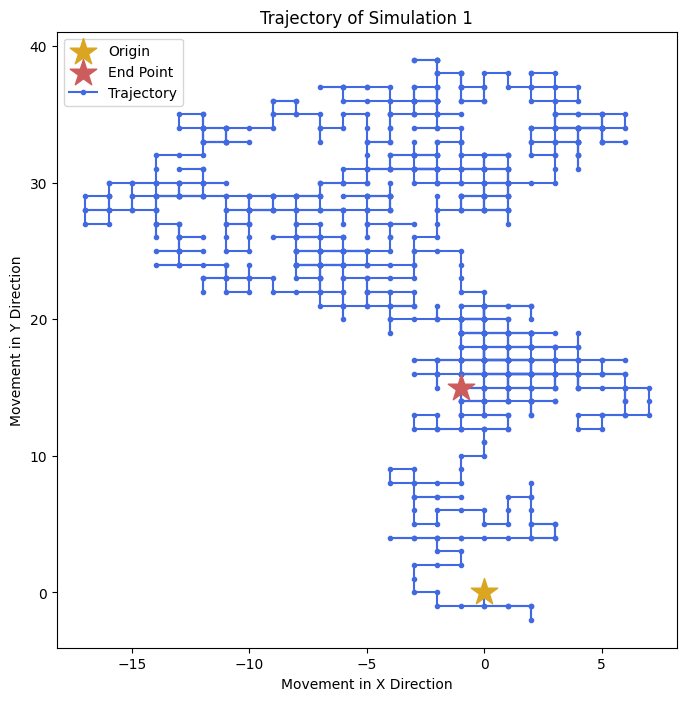

The final displacement from the origin for Simulation 2 is 25.2982 units.
The path taken by this simulation is: 
 [(0, 0), (0, -1), (1, -1), (2, -1), (1, -1), (1, -2), (1, -3), (1, -4), (0, -4), (0, -5), (1, -5), (2, -5), (2, -6), (2, -7), (2, -6), (3, -6), (3, -7), (3, -8), (4, -8), (4, -7), (4, -8), (4, -9), (5, -9), (5, -8), (5, -9), (5, -10), (5, -9), (5, -10), (4, -10), (5, -10), (6, -10), (6, -11), (5, -11), (4, -11), (4, -10), (3, -10), (3, -11), (4, -11), (4, -10), (4, -11), (3, -11), (4, -11), (3, -11), (4, -11), (4, -12), (4, -13), (4, -12), (3, -12), (3, -13), (3, -14), (4, -14), (4, -13), (4, -14), (4, -13), (4, -12), (3, -12), (2, -12), (1, -12), (2, -12), (1, -12), (2, -12), (3, -12), (3, -13), (4, -13), (4, -12), (3, -12), (3, -13), (3, -12), (4, -12), (4, -11), (4, -10), (4, -11), (3, -11), (3, -12), (4, -12), (4, -13), (4, -12), (4, -11), (4, -12), (3, -12), (4, -12), (3, -12), (3, -11), (4, -11), (4, -10), (5, -10), (5, -11), (4, -11), (3, -11), (4, -11), (5, -11), (4

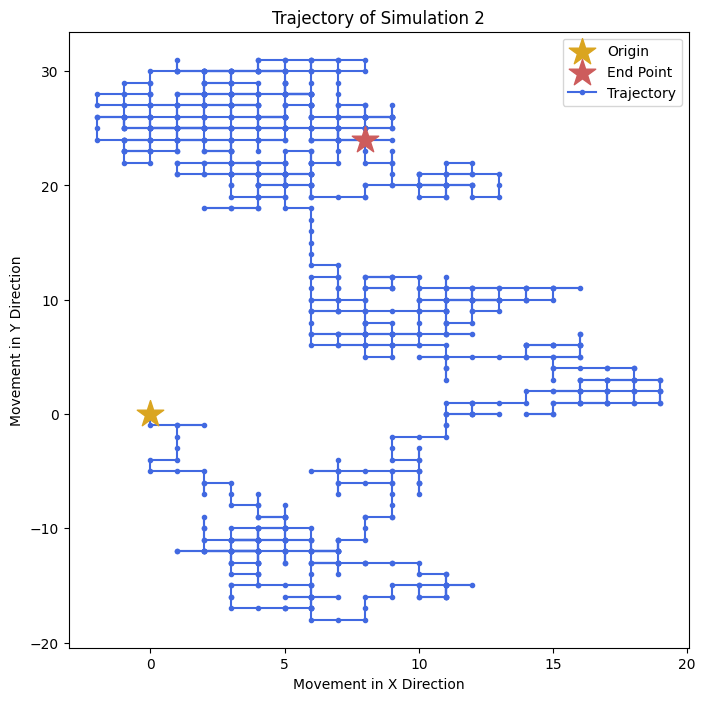

The final displacement from the origin for Simulation 3 is 8.6023 units.
The path taken by this simulation is: 
 [(0, 0), (0, -1), (-1, -1), (-1, -2), (-1, -1), (-1, 0), (-2, 0), (-1, 0), (-1, 1), (-1, 2), (-1, 1), (-1, 2), (-1, 1), (-1, 0), (0, 0), (0, -1), (0, -2), (1, -2), (2, -2), (1, -2), (0, -2), (0, -3), (1, -3), (0, -3), (0, -4), (0, -5), (0, -4), (-1, -4), (-1, -5), (-2, -5), (-2, -4), (-2, -5), (-2, -6), (-2, -5), (-3, -5), (-2, -5), (-1, -5), (-2, -5), (-2, -6), (-3, -6), (-3, -5), (-2, -5), (-2, -4), (-3, -4), (-3, -3), (-4, -3), (-4, -4), (-4, -3), (-4, -2), (-4, -1), (-4, 0), (-5, 0), (-4, 0), (-4, -1), (-4, -2), (-4, -1), (-4, 0), (-5, 0), (-4, 0), (-3, 0), (-2, 0), (-1, 0), (0, 0), (1, 0), (1, -1), (0, -1), (-1, -1), (-2, -1), (-2, 0), (-2, 1), (-2, 2), (-2, 1), (-2, 2), (-3, 2), (-2, 2), (-2, 3), (-3, 3), (-3, 2), (-2, 2), (-1, 2), (-1, 3), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (1, 5), (0, 5), (-1, 5), (0, 5), (0, 4), (0, 5), (-1, 5), (-1, 6), (-2, 6), (-2, 5), (-2, 

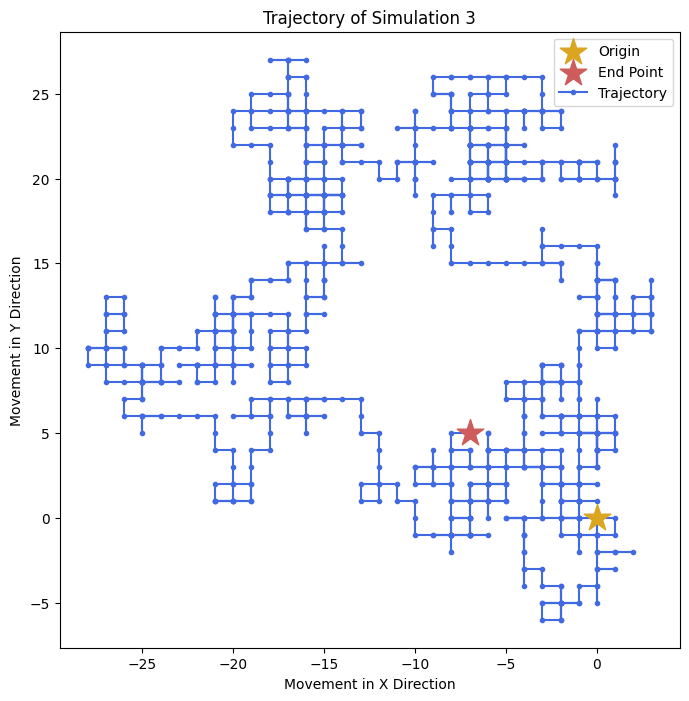

In [53]:
plot_trajectories(random_walk(1000,1000, seed=123456)[1])

## Discussion of Results

I ran my code above using the parameters N = 1000, M = 1000, and a seed of 123456. The average final position of the particle after 1000 trials was determined to be roughly 27.4905 units from the origin. This result is consistent with the theoretical expectation that $ R \sim \sqrt{N}$, where the predicted displacement for N = 1000 is about 31.6227. There is a slight discrepancy between the value found in my simulation and the theoretical value, however this can be easily explained by the relatively small number of trials.
The random nature of this process can be seen directly by looking at the average displacement of the first three trials, where $ R_1 = 15.0333 $ units, $ R_2 = 25.2982 $ units, and $ R_3 = 8.6023 $ units. Despite each simulation involving the exact same number of steps, each value is wildly different from the others because of the randomization of the direction of each step, and as described above, the paths followed by the particle in each simulation are highly jagged and irregular.  

All in all, my results accurately reflect the expected trend, and support the idea from statistical mechanics that random motion tends to have predictable patterns and trends after a large enough number of trials.

#### Original non-split up version of my code:

In [ ]:
import numpy as np
from matplotlib import pyplot as plt 

def random_walk(N, M):

    """
    Function simulates a 2D random walk, where a particle takes N 1 unit steps in a random direction (N, S, E, W) for M simulations. It then calculates the final displacement 
        for each simulation and averages it across all M simulations before plotting the trajectory of the first three simulations. 
        The function then returns the plots, the average final displacement from the origin, and the trajectory coordinates for each simulation.  

    Parameters:
    N: The number of steps taken in each simulation.
    M: The number of simulations to run.

    Returns:
    avg_R_tot: The average final displacement from the origin after M simulations.
    trajectories: A list of tuples containing the x and y coordinates of the trajectory for each simulation.

    """
    
    # SIMULATION CODE 

    trajectories = []
    avg_R = 0
    
    # Runs simulation M times, with each time taking N steps.
    for i in range(M):
        x, y = 0, 0
        x_coords, y_coords = [x], [y]
        for j in range(N):
            # Chooses a random direction to walk in.  
            dir = np.random.randint(0,4)
            
            # Let 0 = North (y+1), 1 = South (y-1), 2 = East (x+1), 3 = West (x-1)
            if dir == 0:
                y += 1
            elif dir == 1:
                y -= 1
            elif dir == 2:
                x += 1
            elif dir == 3:
                x -=1
            
            # Append new coordinates to each list.
            x_coords.append(x)
            y_coords.append(y)

        # Append the trajectory of this simulation to a list of all trajectories.    
        trajectories.append((x_coords, y_coords))    

        # Calculate the final displacement R from the origin after N steps using last value in each list
        R_N_Steps = np.sqrt(x_coords[-1]**2 + y_coords[-1]**2)

        # Add final displacement to variable that calculates the total displacement for all M simulations.
        avg_R += R_N_Steps
    
    # Calculate the average final displacement after running the simulation M times
    avg_R_tot = avg_R / M
    
    # PLOTTING CODE 

    # Plot the trajectory of the random walk for the first three simulations.

    # For statement allows me to loop through the first three simulations and plot each one separately.
    for sim_number, (x_coords, y_coords) in enumerate(trajectories[:3], start=1):
        print(f"Trajectory of Simulation {sim_number}: \n Path: {list(zip(x_coords, y_coords))}")

        # Adds star markers to indicate the origin & end point of the trajectory & the trajectory itself
        plt.figure(figsize=(10,10))
        plt.scatter([0], [0], c='goldenrod', marker='*', s=400, label='Origin', zorder=2)
        plt.plot(x_coords, y_coords, c='royalblue', marker='.', zorder=1, label='Trajectory')
        plt.scatter(x_coords[-1], y_coords[-1], c='indianred', marker='*', s=400, label='End Point', zorder=2)


        plt.xlabel('Movement in X Direction')
        plt.ylabel('Movement in Y Direction')
        plt.title(f'Trajectory of Simulation {sim_number}')
        plt.legend()
        plt.show()


    return float(avg_R_tot), trajectories

